In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load dataset
df = pd.read_csv("APO.csv")

# Format and sort dates
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Add technical indicators
df['SMA_10'] = df['Close_Prices'].rolling(window=10).mean()
df['EMA_10'] = df['Close_Prices'].ewm(span=10, adjust=False).mean()
df['RSI'] = 100 - (100 / (1 + (df['Close_Prices'].pct_change().rolling(14).mean() /  
                               df['Close_Prices'].pct_change().rolling(14).std())))
df['MACD'] = df['Close_Prices'].ewm(span=12).mean() - df['Close_Prices'].ewm(span=26).mean()
df['Bollinger_High'] = df['Close_Prices'].rolling(20).mean() + 2 * df['Close_Prices'].rolling(20).std()
df['Bollinger_Low'] = df['Close_Prices'].rolling(20).mean() - 2 * df['Close_Prices'].rolling(20).std()

# 5-day forward return and classification label
df['Target_Change'] = df['Close_Prices'].shift(-5) / df['Close_Prices'] - 1
df['Target_Class'] = (df['Target_Change'] > 0).astype(int)

# Drop rows with NaNs from rolling windows and shifts
df.dropna(inplace=True)

In [ ]:
features = ['Close_Prices', 'Open_Prices', 'High_Prices', 'Low_Prices', 'Volume', 
            'SMA_10', 'EMA_10', 'RSI', 'MACD', 'Bollinger_High', 'Bollinger_Low']

X = df[features]
y_reg = df['Target_Change'].values.reshape(-1, 1)
y_class = df['Target_Class'].values.reshape(-1, 1)

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Sequence creation
def create_sequences(data, labels_reg, labels_class, seq_length):
    X_seq, y_seq_reg, y_seq_class = [], [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq_reg.append(labels_reg[i+seq_length])
        y_seq_class.append(labels_class[i+seq_length])
    return np.array(X_seq), np.array(y_seq_reg), np.array(y_seq_class)

SEQ_LENGTH = 60
X_seq, y_reg_seq, y_class_seq = create_sequences(X_scaled, y_reg, y_class, SEQ_LENGTH)

# Time-based split
dates = df['Date'].values[SEQ_LENGTH:]
split_date = np.datetime64('2024-01-01')
split_idx = np.where(dates >= split_date)[0][0]

X_train, y_reg_train, y_class_train = X_seq[:split_idx], y_reg_seq[:split_idx], y_class_seq[:split_idx]
X_test, y_reg_test, y_class_test = X_seq[split_idx:], y_reg_seq[split_idx:], y_class_seq[split_idx:]

In [ ]:
# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_reg_train = torch.tensor(y_reg_train, dtype=torch.float32).to(device)
y_class_train = torch.tensor(y_class_train, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_reg_test = torch.tensor(y_reg_test, dtype=torch.float32).to(device)
y_class_test = torch.tensor(y_class_test, dtype=torch.float32).to(device)

In [ ]:
class LSTMRegClass(nn.Module):
    def __init__(self, input_size=11, hidden_size=512, num_layers=2):
        super(LSTMRegClass, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.reg_head = nn.Linear(hidden_size, 1)
        self.cls_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        return self.reg_head(last), torch.sigmoid(self.cls_head(last))

# Initialize model
model = LSTMRegClass().to(device)
criterion_reg = nn.MSELoss()
criterion_cls = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
EPOCHS = 150
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred_reg, pred_cls = model(X_train)
    loss_reg = criterion_reg(pred_reg, y_reg_train)
    loss_cls = criterion_cls(pred_cls, y_class_train)
    loss = loss_reg + loss_cls
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Reg Loss: {loss_reg.item():.4f}, Cls Loss: {loss_cls.item():.4f}")

Epoch 10/150, Reg Loss: 0.0026, Cls Loss: 0.6888
Epoch 20/150, Reg Loss: 0.0026, Cls Loss: 0.6886
Epoch 30/150, Reg Loss: 0.0026, Cls Loss: 0.6883
Epoch 40/150, Reg Loss: 0.0026, Cls Loss: 0.6883
Epoch 50/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 60/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 70/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 80/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 90/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 100/150, Reg Loss: 0.0026, Cls Loss: 0.6882
Epoch 110/150, Reg Loss: 0.0026, Cls Loss: 0.6881
Epoch 120/150, Reg Loss: 0.0026, Cls Loss: 0.6880
Epoch 130/150, Reg Loss: 0.0026, Cls Loss: 0.6878
Epoch 140/150, Reg Loss: 0.0026, Cls Loss: 0.6877
Epoch 150/150, Reg Loss: 0.0026, Cls Loss: 0.6875


In [ ]:
# Evaluate model
model.eval()
with torch.no_grad():
    pred_reg, pred_cls = model(X_test)
    pred_reg = pred_reg.cpu().numpy()
    pred_cls = (pred_cls.cpu().numpy() > 0.5).astype(int)
    y_reg_np = y_reg_test.cpu().numpy()
    y_cls_np = y_class_test.cpu().numpy()
    
# Regression metrics
rmse = np.sqrt(mean_squared_error(y_reg_np, pred_reg))
mae = mean_absolute_error(y_reg_np, pred_reg)
r2 = r2_score(y_reg_np, pred_reg)

# Classification metric
directional_accuracy = accuracy_score(y_cls_np, pred_cls)

print(f"\n1-Week Return Prediction")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")



1-Week Return Prediction
RMSE: 0.0479
MAE: 0.0350
R-squared: -0.1571
Directional Accuracy: 57.95%


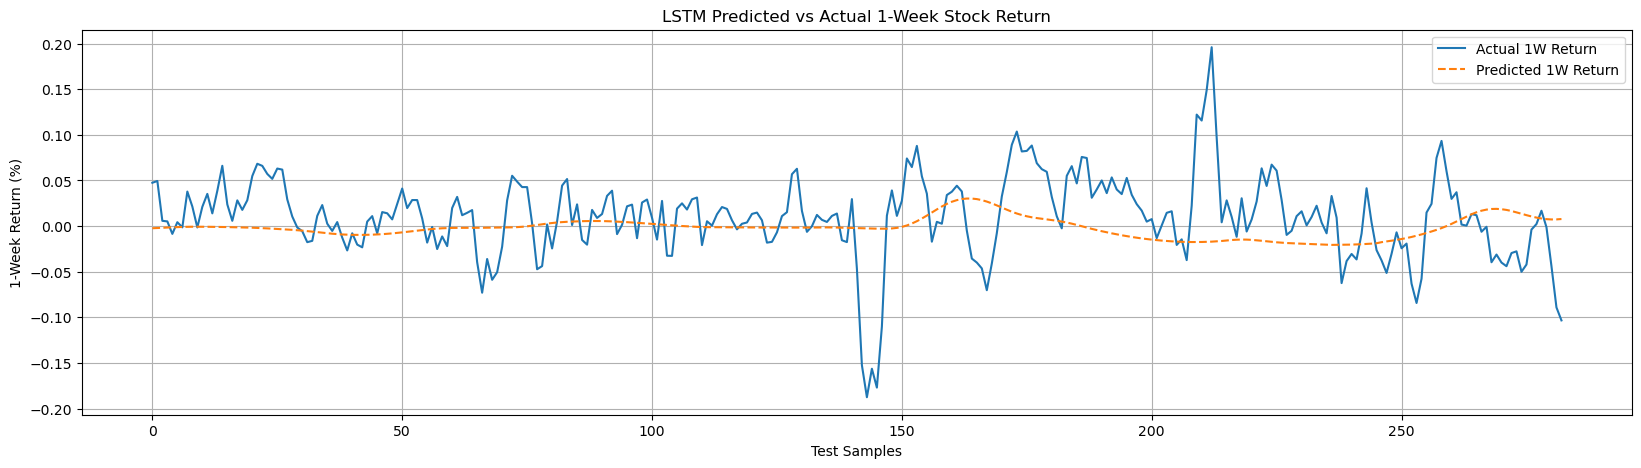

In [11]:
plt.figure(figsize=(20, 5))
plt.plot(y_reg_np, label='Actual 1W Return')
plt.plot(pred_reg, label='Predicted 1W Return', linestyle='dashed')
plt.legend()
plt.xlabel("Test Samples")
plt.ylabel("1-Week Return (%)")
plt.title("LSTM Predicted vs Actual 1-Week Stock Return")
plt.grid(True)
plt.show()
